In [2]:
import pandas as pd
import sys
import os

# Ensure the path to the DEModelHandler is correct
sys.path.append(os.path.abspath("../SubjectModels/de_model"))
from de_handler import DEModelHandler  

# Ensure the path to the FSDModelHandler is correct
sys.path.append(os.path.abspath("../SubjectModels/fsd_model"))
from fsd_handler import FSDModelHandler  

# Ensure the path to the Math3ModelHandler is correct
sys.path.append(os.path.abspath("../SubjectModels/math3_model"))
from math3_handler import Math3ModelHandler  

# Ensure the path to the PythonModelHandler is correct
sys.path.append(os.path.abspath("../SubjectModels/python_model"))
from python_handler import PythonModelHandler  

df = pd.read_csv("../../dataset/train_dataset.csv")

# Drop the irrelevant, data leak columns
df_clean = df.drop(
    columns=[
        "Student ID",
        "Mentor-1",
        "Mentor-2",
        "Mentor-3",
        "Roll-2",
        "Roll-3",
        "Math-3 Theory",
        "DE Practical",
        "FSD Theory",
        "FSD Practical",
        "Python Theory",
        "Python Practical",
        "Communication Theory",
        "Law Theory",
    ]
)

# columns for Semester 1 core subjects
sem1_columns = [
    "Math-1 Theory",
    "Physics Theory",
    "Java-1 Theory",
    "Software Engineering Theory",
]

# Calculate Semester 1 Percentage as the average of core subject scores
# scores are numerical and out of 100
df_clean["Sem 1 Percentage"] = df_clean[sem1_columns].mean(axis=1).round(2)

# columns for Semester 2 core subjects
sem2_columns = [
    "Math-2 Theory",
    "Data Structures using Java Theory",
    "DBMS Theory",
    "Fundamental of Electronics and Electrical Theory",
    "Java-2 Theory",
]

# Calculate Semester 2 Percentage as the average of core subject scores
# scores are numerical and out of 100
df_clean["Sem 2 Percentage"] = df_clean[sem2_columns].mean(axis=1).round(2)

# Rename columns Div-1, Div-2, Div-3 to Section-1, Section-2, Section-3
df_clean = df_clean.rename(
    columns={"Div-1": "Section-1", "Div-2": "Section-2", "Div-3": "Section-3"}
)

# Transform values in Section-1, Section-2, Section-3 to keep only the first character
# Thus we get Only Department
for section in ["Section-1", "Section-2", "Section-3"]:
    df_clean[section] = df_clean[section].str[0]

# adding DE predicted column
preprocessor = DEModelHandler()
fe_de = preprocessor.predict_from_model(
    df,
    model_path="../SubjectModels/de_model/de_model.joblib",
    return_type="df"
)

# Add the predicted DE Theory marks to df_clean
df_clean["Predicted DE Theory"] = fe_de["Predicted DE Theory"]


# adding FSD predicted column
preprocessor = FSDModelHandler()
fe_fsd = preprocessor.predict_from_model(
    df,
    model_path="../SubjectModels/fsd_model/fsd_model.joblib",
    return_type="df"
)

# Add the predicted FSD Theory marks to df_clean
df_clean["Predicted FSD Theory"] = fe_fsd["Predicted FSD Theory"]


# adding Math3 predicted column
preprocessor = Math3ModelHandler()
fe_math3 = preprocessor.predict_from_model(
    df,
    model_path="../SubjectModels/math3_model/math3_model.joblib",
    return_type="df"
)

# Add the predicted Math3 Theory marks to df_clean
df_clean["Predicted Math-3 Theory"] = fe_math3["Predicted Math-3 Theory"]


# adding Python predicted column
preprocessor = PythonModelHandler()
fe_python = preprocessor.predict_from_model(
    df,
    model_path="../SubjectModels/python_model/python_model.joblib",
    return_type="df"
)

# Add the predicted Python Theory marks to df_clean
df_clean["Predicted Python Theory"] = fe_python["Predicted Python Theory"]

#  Calculate predicted Semester 3 percentage (mean of 4 predicted subject marks)
sem3_subjects = [
    "Predicted Math-3 Theory",
    "Predicted DE Theory",
    "Predicted FSD Theory",
    "Predicted Python Theory",
]

df_clean["Predicted Sem 3 Percentage"] = df_clean[sem3_subjects].mean(axis=1).round(2)

df_clean["Sem 1 Percentile"] = df_clean["Sem 1 Percentage"].rank(pct=True) * 100
df_clean["Sem 2 Percentile"] = df_clean["Sem 2 Percentage"].rank(pct=True) * 100
df_clean["Predicted Sem 3 Percentile"] = df_clean["Predicted Sem 3 Percentage"].rank(pct=True) * 100

# Round for consistency
df_clean[["Sem 1 Percentile", "Sem 2 Percentile", "Predicted Sem 3 Percentile"]] = df_clean[
    ["Sem 1 Percentile", "Sem 2 Percentile", "Predicted Sem 3 Percentile"]
].round(2)

df_clean["Predicted Percentile Drop"] = (
    df_clean["Sem 2 Percentile"] - df_clean["Predicted Sem 3 Percentile"]
).round(2)

df_clean["Predicted Risk Flag"] = df_clean["Predicted Percentile Drop"] > 10

# Columns for Semester 3 core theory subjects
sem3_columns = [
    "Math-3 Theory",
    "DE Theory",
    "FSD Theory",
    "Python Theory",
]

# Calculate Semester 3 Total as the sum of core subject scores
df["Sem 3 Percentage"] = (df[sem3_columns].sum(axis=1) / 4).round(2)

df_clean["Sem 3 Percentile"] = df["Sem 3 Percentage"].rank(pct=True) * 100

df_clean["Percentile Drop"] = (
    df_clean["Sem 2 Percentile"] - df_clean["Sem 3 Percentile"]
).round(2)

df_clean["Risk Flag"] = df_clean["Percentile Drop"] > 10

columns_to_drop = [
    "Sem 3 Percentile",
    "Percentile Drop"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

print(df_clean.head())

  Gender Religion Branch Section-1 Section-2 Section-3  Roll-1  Math-1 Theory  \
0      M    Hindu     CE         D         D         A     350             47   
1      F    Hindu    CST         B         B         D      18             84   
2      F    Hindu   AIML         A         A         C      23             74   
3      M    Hindu    CST         B         B         D     212             55   
4      M    Hindu    CST         B         B         D     208             38   

   Physics Theory  Physics Practical  ...  Predicted FSD Theory  \
0              48                 75  ...             72.266535   
1              83                 81  ...             87.523458   
2              85                 86  ...             89.409752   
3              69                 82  ...             79.807055   
4              59                 74  ...             56.474296   

   Predicted Math-3 Theory  Predicted Python Theory  \
0                56.352210                71.642156   


m:\All Personal Projects\DONE\PG\PredictGrad-main\.env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


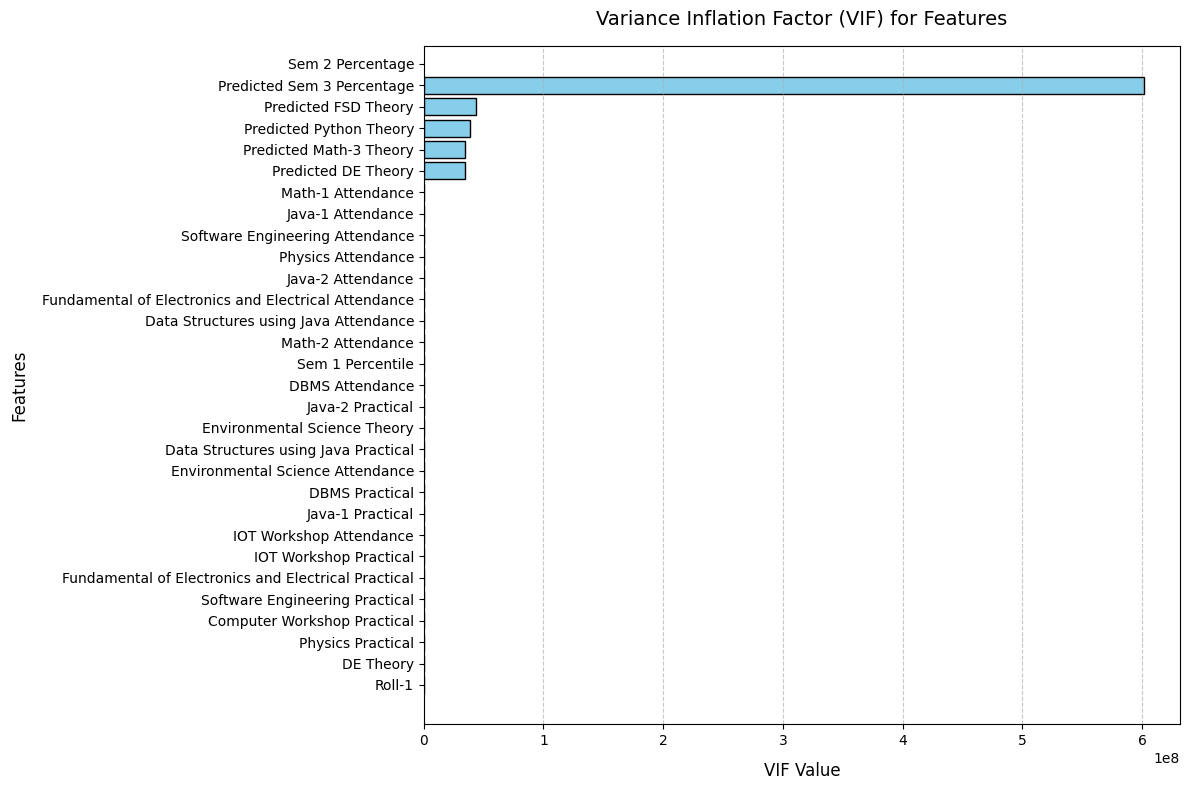

                                              Feature           VIF
1                                       Math-1 Theory           inf
2                                      Physics Theory           inf
4                                       Java-1 Theory           inf
6                         Software Engineering Theory           inf
32                                   Sem 1 Percentage           inf
42                          Predicted Percentile Drop           inf
18                                      Java-2 Theory           inf
16   Fundamental of Electronics and Electrical Theory           inf
14                                        DBMS Theory           inf
12                  Data Structures using Java Theory           inf
11                                      Math-2 Theory           inf
41                         Predicted Sem 3 Percentile           inf
40                                   Sem 2 Percentile           inf
33                                   Sem 2 Perce

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
numeric_df = df_clean.select_dtypes(include=["number"]).dropna()

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(numeric_df.values, i)
    for i in range(numeric_df.shape[1])
]

# Sort by VIF for clarity
vif_data = vif_data.sort_values("VIF", ascending=False)

# Plot the VIF values with better spacing
plt.figure(figsize=(12, 8))
bars = plt.barh(vif_data["Feature"], vif_data["VIF"], color="skyblue", edgecolor="black")

# Labels and title with padding
plt.xlabel("VIF Value", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.title("Variance Inflation Factor (VIF) for Features", fontsize=14, pad=15)

# Grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Invert y-axis so highest VIF is on top
plt.gca().invert_yaxis()

# Adjust layout for spacing
plt.tight_layout()
plt.show()

print(vif_data)

C:\Users\Kiran\AppData\Local\Temp\ipykernel_14676\2819508447.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_total = pairs.groupby("Primary Feature")["AbsCorr"].sum().max()


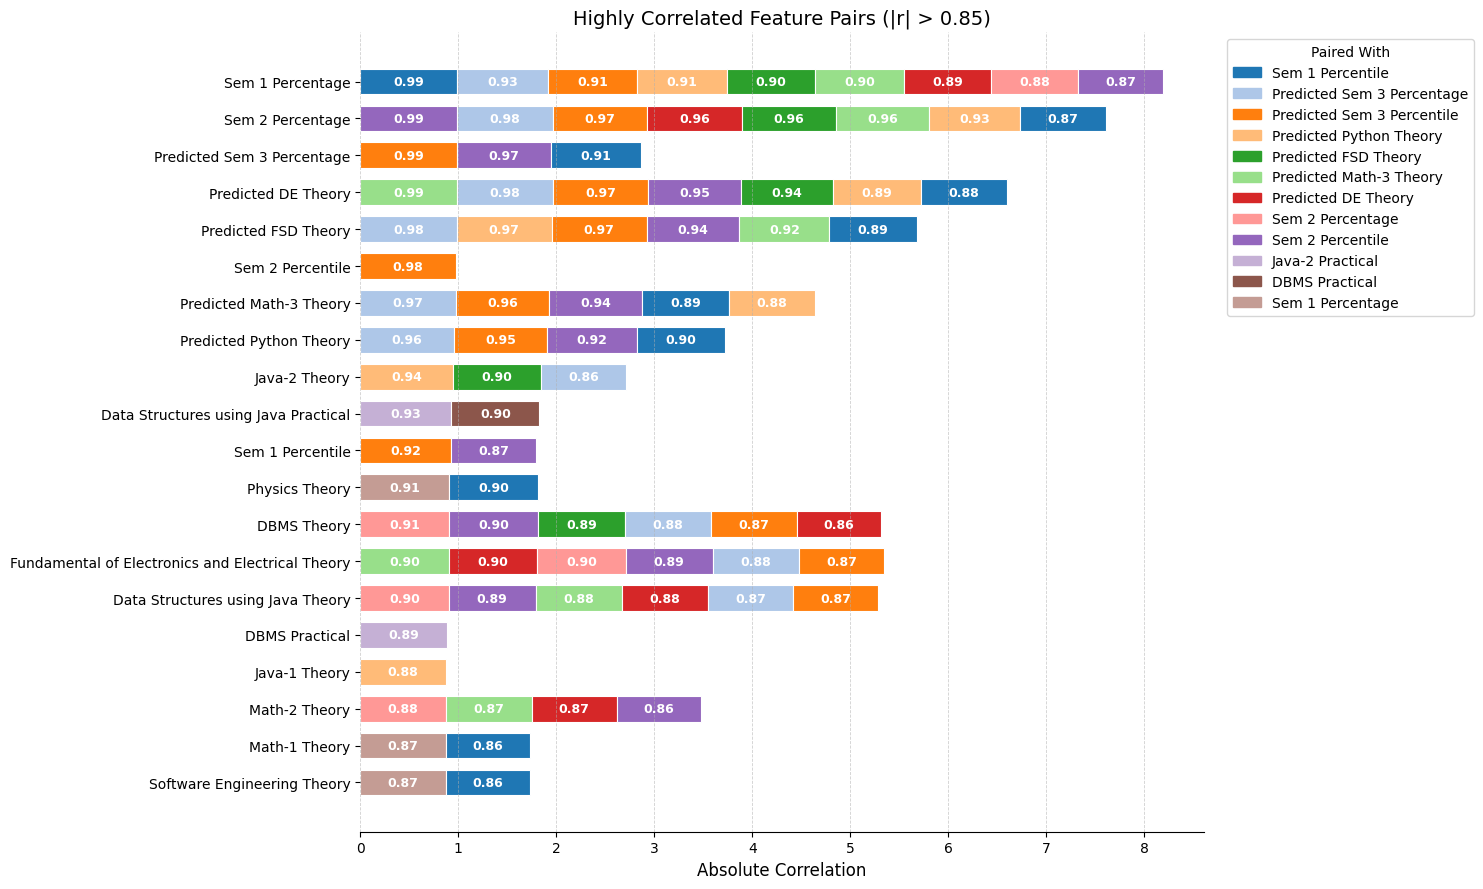

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) build correlation pairs (numeric-only columns) ---
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

threshold = 0.85
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only
pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
)
pairs.columns = ["Primary Feature", "Paired With", "Correlation"]
pairs = pairs[ pairs["Correlation"].abs() > threshold ].copy()
pairs["AbsCorr"] = pairs["Correlation"].abs()

if pairs.empty:
    raise ValueError(f"No correlated pairs found with |r| > {threshold}")

# --- 2) order Primary Features by their strongest correlation (desc) ---
order = (
    pairs.groupby("Primary Feature")["AbsCorr"]
    .max()
    .sort_values(ascending=False)
    .index
)
pairs["Primary Feature"] = pd.Categorical(pairs["Primary Feature"], categories=order, ordered=True)

# for nicer drawing: make sure each row is ordered from highest->lowest segment
pairs = pairs.sort_values(["Primary Feature", "AbsCorr"], ascending=[True, False])

# --- 3) color mapping for 'Paired With' (distinct but pleasant palette) ---
unique_pairs = pairs["Paired With"].unique()
palette = sns.color_palette("tab20", n_colors=len(unique_pairs))  # good, varied palette
pair_color_map = {p: palette[i % len(palette)] for i, p in enumerate(unique_pairs)}

# --- 4) plot: per-row stacking (only actual pairs for that row) ---
fig, ax = plt.subplots(figsize=(15, 9))

for primary in order:
    row = pairs[pairs["Primary Feature"] == primary]
    left = 0.0
    for _, r in row.iterrows():
        val = r["AbsCorr"]
        pair = r["Paired With"]
        color = pair_color_map[pair]
        # draw the segment for this pair
        ax.barh(primary, val, left=left, height=0.7, color=color, edgecolor="white", linewidth=0.8)
        # annotate if segment is reasonably wide
        if val >= 0.06:
            ax.text(left + val / 2, primary, f"{val:.2f}", va="center", ha="center", fontsize=9, color="white", fontweight="bold")
        left += val

# --- 5) aesthetics ---
ax.set_xlabel("Absolute Correlation", fontsize=12)
ax.set_title("Highly Correlated Feature Pairs (|r| > 0.85)", fontsize=14)
ax.invert_yaxis()                      # strongest (first in 'order') at the top
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)
sns.despine(left=True, bottom=False)

# legend (one handle per Paired With)
handles = [plt.Rectangle((0, 0), 1, 1, color=pair_color_map[p]) for p in unique_pairs]
ax.legend(handles, unique_pairs, title="Paired With", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# set x limit a bit above the row that has the largest total stacked width (for spacing)
max_total = pairs.groupby("Primary Feature")["AbsCorr"].sum().max()
ax.set_xlim(0, max(1.0, max_total) * 1.05)

plt.tight_layout()
plt.show()


C:\Users\Kiran\AppData\Local\Temp\ipykernel_14676\946225374.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xmax = pairs.groupby("Primary Feature")["AbsCorr"].sum().max()


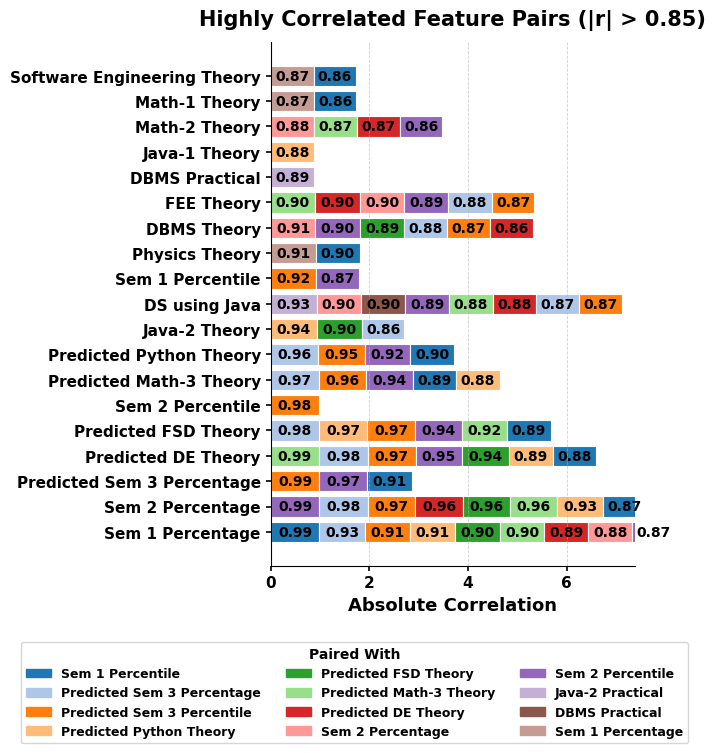

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) build correlation pairs (numeric-only columns) ---
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

threshold = 0.85
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
)
pairs.columns = ["Primary Feature", "Paired With", "Correlation"]
pairs = pairs[pairs["Correlation"].abs() > threshold].copy()
pairs["AbsCorr"] = pairs["Correlation"].abs()

if pairs.empty:
    raise ValueError(f"No correlated pairs found with |r| > {threshold}")

# --- 2) rename long features ---
rename_map = {
    "Fundamental of Electronics and Electrical Theory": "FEE Theory",
    "Data Structures using Java Theory": "DS using Java",
    "Data Structures using Java Practical": "DS using Java"
}
pairs["Primary Feature"] = pairs["Primary Feature"].replace(rename_map)
pairs["Paired With"] = pairs["Paired With"].replace(rename_map)

# --- 3) order ---
order = (
    pairs.groupby("Primary Feature")["AbsCorr"]
    .max()
    .sort_values(ascending=False)
    .index
)
pairs["Primary Feature"] = pd.Categorical(
    pairs["Primary Feature"], categories=order, ordered=True
)
pairs = pairs.sort_values(["Primary Feature", "AbsCorr"], ascending=[True, False])

# --- 4) color mapping ---
unique_pairs = pairs["Paired With"].unique()
palette = sns.color_palette("tab20", n_colors=len(unique_pairs))
pair_color_map = {p: palette[i % len(palette)] for i, p in enumerate(unique_pairs)}

# --- 5) plot (horizontal stacked bars) ---
fig, ax = plt.subplots(figsize=(7, 10))  # tall, narrow for paper column

for i, primary in enumerate(order):
    row = pairs[pairs["Primary Feature"] == primary]
    left = 0.0
    for _, r in row.iterrows():
        val = r["AbsCorr"]
        pair = r["Paired With"]
        color = pair_color_map[pair]
        ax.barh(primary, val, left=left,
                color=color, edgecolor="white", linewidth=0.8)

        # annotation inside the segment
        if val >= 0.08:
            ax.text(left + val / 2, i, f"{val:.2f}",
                    va="center", ha="center",
                    fontsize=10, color="black", fontweight="bold")
        left += val

# --- 6) aesthetics ---
ax.set_xlabel("Absolute Correlation", fontsize=13, fontweight="bold")
ax.set_title("Highly Correlated Feature Pairs (|r| > 0.85)",
             fontsize=15, fontweight="bold", pad=12)

# y-labels (features) bold
ax.tick_params(axis="y", labelsize=11, width=1.2)
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# x-axis ticks bold too
ax.tick_params(axis="x", labelsize=11, width=1.2)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)
sns.despine(left=False, bottom=False)

# Extend X-axis range by 10% for breathing space
xmax = pairs.groupby("Primary Feature")["AbsCorr"].sum().max()
ax.set_xlim(0, xmax * 0.9)

# Legend with bold text
handles = [plt.Rectangle((0, 0), 1, 1, color=pair_color_map[p]) for p in unique_pairs]
legend = ax.legend(
    handles, unique_pairs, title="Paired With",
    loc="lower center", bbox_to_anchor=(0.23, -0.35),  # shifted left
    ncol=3, frameon=True, fontsize=9,
    title_fontsize=10, fancybox=True
)

# Make legend labels bold
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_title().set_fontweight("bold")

plt.tight_layout(rect=[0, 0.15, 1, 1])  # space for legend
plt.show()

C:\Users\Kiran\AppData\Local\Temp\ipykernel_19920\2990794216.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels, fontsize=20, weight="bold")


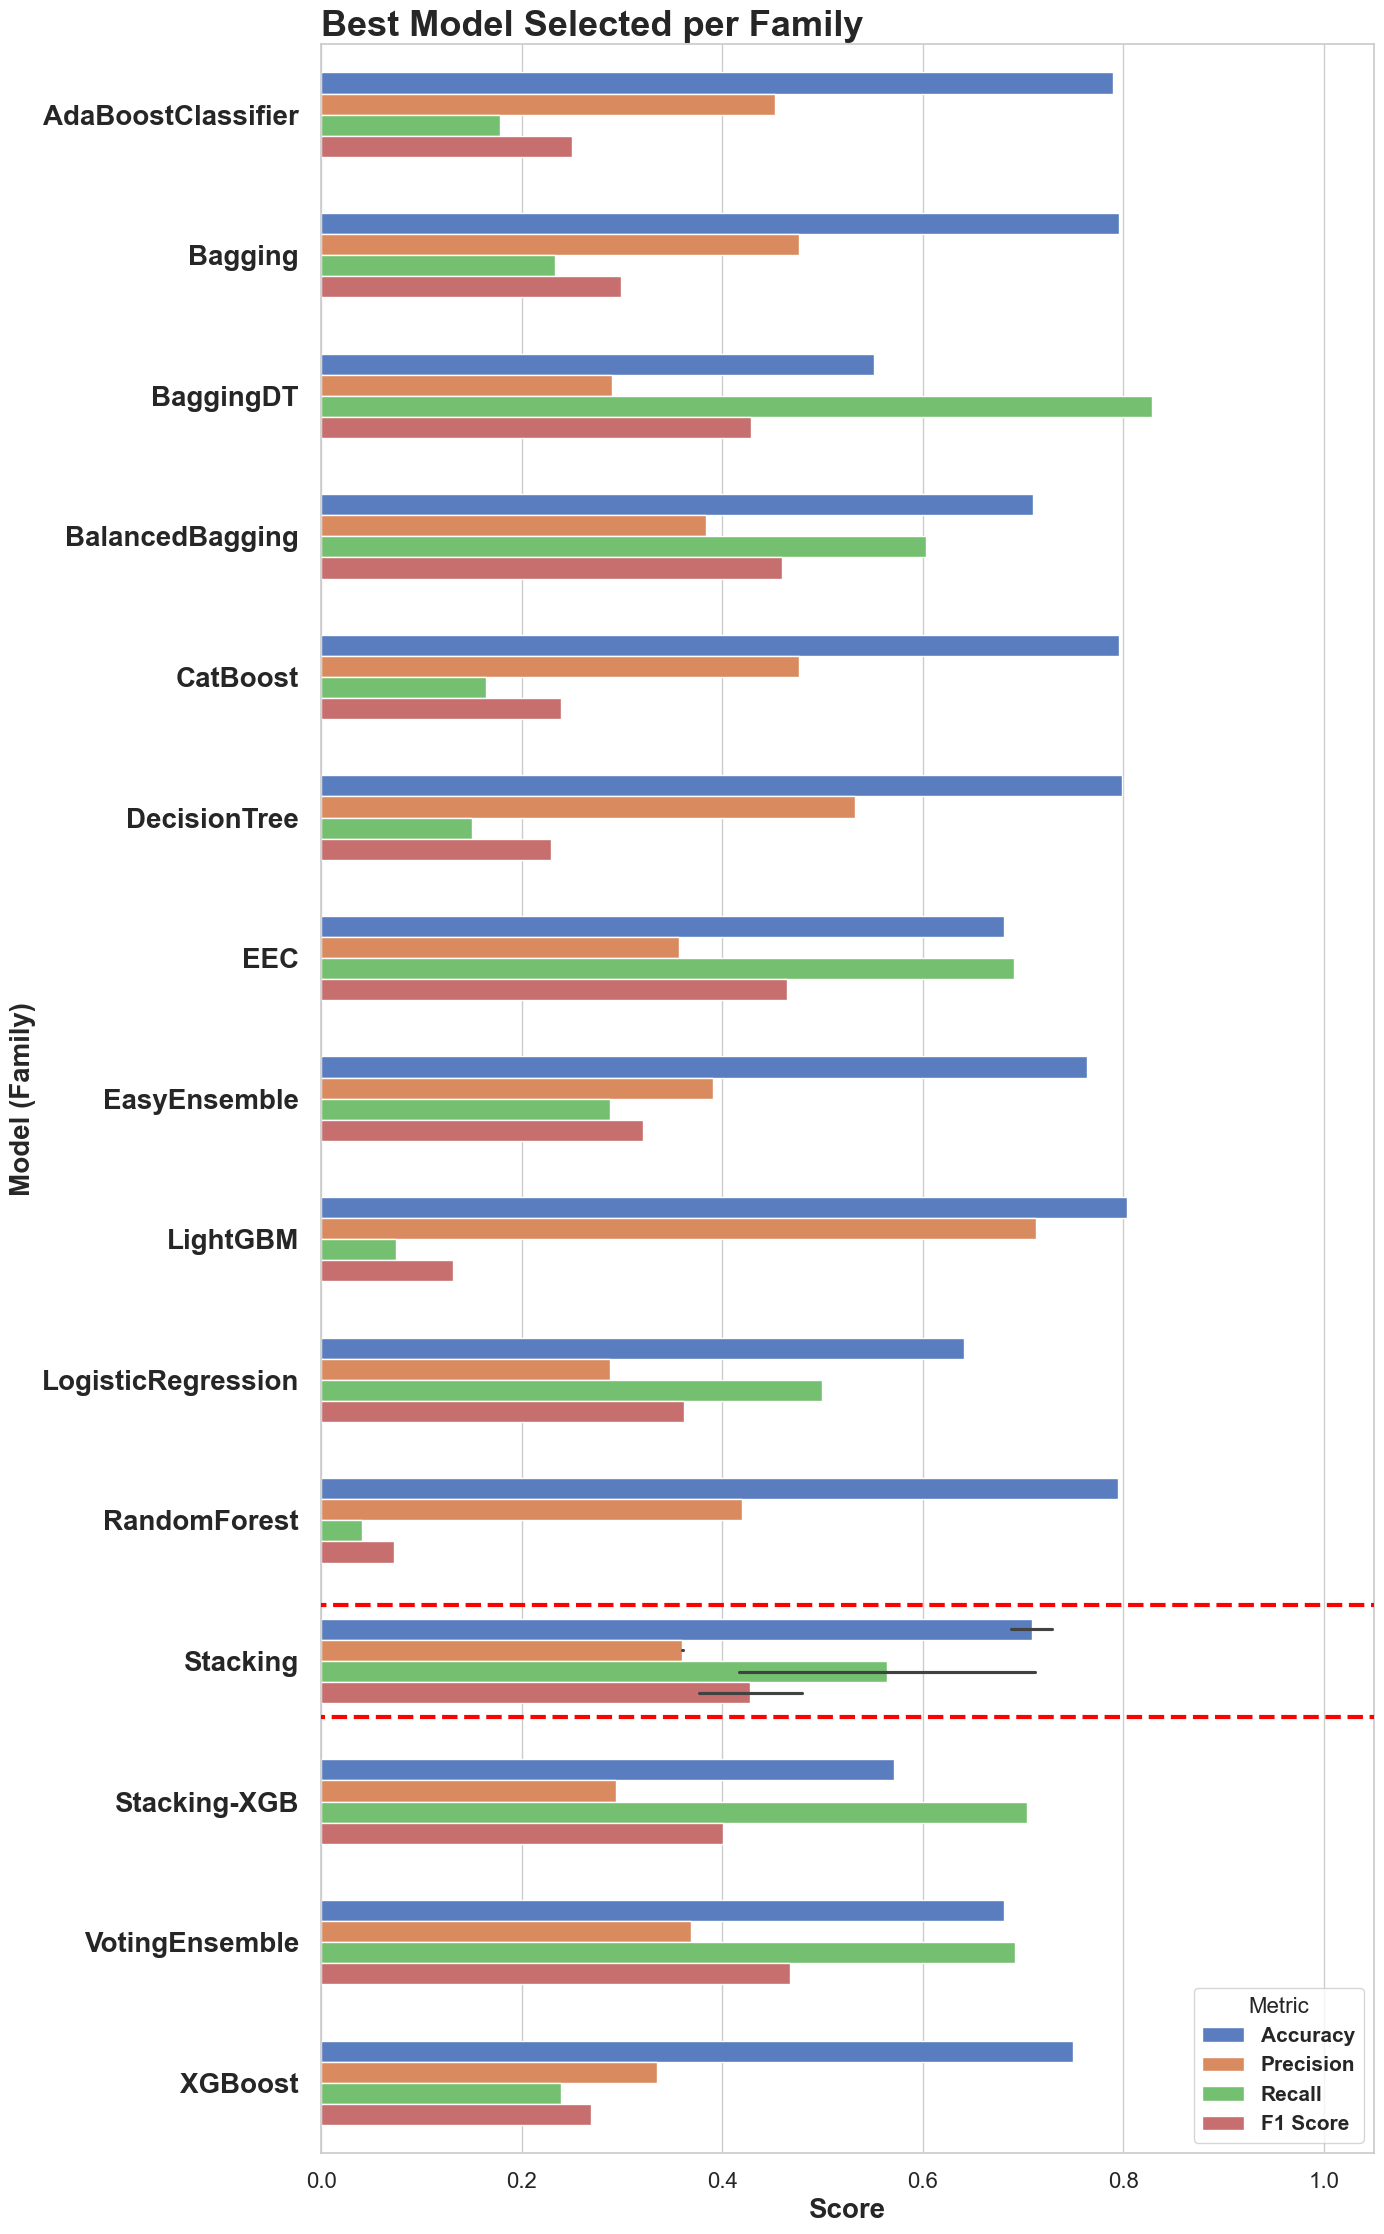

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Rectangle
import re

# Load CSV
df = pd.read_csv("risk_model_metrics.csv")

# --- Remove unwanted models ---
df = df[~df["Name"].str.contains("SVC", case=False)]
df = df[~df["Name"].str.contains("DummyClassifier", case=False)]
df = df[df["Name"] != "ASDSD"]

# Highlighted best model
highlighted_model = "Stacking (CatBoost+EEC+BalancedBagging-LGBM)"

# Manual families mapping
manual_families = {
    "BaggingDT": ["BaggingDT", "BaggingDTClassifier"],
    "DecisionTree": ["DecisionTree", "DecisionTreeClassifier", "DescrionTree"],
    "EasyEnsemble": ["EasyEnsembleClassifier", "EasyEnsemble", "EasyEnsemble-Top20Feat"],
    "RandomForest": ["RandomForest", "RandomForestClassifier"],
    "BalancedBagging": ["BalancedBagging", "BalancedBaggingClassifier"],
}

def get_family(name):
    if name == highlighted_model:
        return highlighted_model
    for fam, variants in manual_families.items():
        if any(v.lower() in name.lower() for v in variants):
            return fam
    if "+" in name:
        return name.split("+")[0]
    return re.split(r"[^A-Za-z]", name)[0]

df["BaseName"] = df["Name"].apply(get_family)
rename_map = {"SDSDDS": "SDSD"}
df["BaseName"] = df["BaseName"].replace(rename_map)

def filter_redundant(df, highlighted_model):
    keep_rows = []
    for base, group in df.groupby("BaseName"):
        if highlighted_model in group["Name"].values:
            best_row = group[group["Name"] == highlighted_model].iloc[0]
        else:
            best_row = group.sort_values(
                by=["Accuracy", "F1 Score", "Recall", "Precision"],
                ascending=[False, False, False, False]
            ).iloc[0]
        keep_rows.append(best_row)
    return pd.DataFrame(keep_rows)

df = filter_redundant(df, highlighted_model)
df.loc[df["Name"] == highlighted_model, "BaseName"] = "Stacking"
df = df.sort_values(by="BaseName").reset_index(drop=True)

# Prepare for plotting
metrics_melted = df.melt(
    id_vars=["BaseName"],
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

# Number of models -> used to scale figure height
n_models = df["BaseName"].nunique()
fig_h = max(8, n_models * 1.5)   # increased multiplier for more space between models

sns.set(style="whitegrid")
plt.figure(figsize=(14, fig_h))

# Barplot with thinner bars
ax = sns.barplot(
    data=metrics_melted,
    y="BaseName",
    x="Score",
    hue="Metric",
    palette="muted",
    orient="h",
    dodge=True,
    width=0.6,    # thinner bars
    edgecolor=None
)

# Compute y-tick positions and labels
yticks = ax.get_yticks()
yticklabels = [t.get_text() for t in ax.get_yticklabels()]

# Add red rectangle covering all bars of the best model
if "Stacking" in yticklabels:
    idx = yticklabels.index("Stacking")
    ycenter = yticks[idx]
    box_height = 0.8  # cover all bars fully but not overlap neighbors
    box_bottom = ycenter - box_height / 2
    ax.add_patch(Rectangle(
        (0 - 0.01, box_bottom),  # slight offset to cover bars neatly
        1.08,                    # extend slightly beyond max score
        box_height,
        fill=False,
        edgecolor="red",
        linewidth=3,
        linestyle="--",
        zorder=7
    ))

# Styling: bigger fonts and bold labels
plt.title("Best Model Selected per Family", fontsize=26, weight="bold", loc="left")
plt.xlabel("Score", fontsize=20, weight="bold")
plt.ylabel("Model (Family)", fontsize=20, weight="bold")
plt.xlim(0, 1.05)

# Y-axis labels styling
ax.set_yticklabels(yticklabels, fontsize=20, weight="bold")
ax.tick_params(axis="x", labelsize=16, pad=8)
ax.tick_params(axis="y", labelsize=20, pad=10)

# Legend styling
legend = plt.legend(title="Metric", loc="lower right", fontsize=15, title_fontsize=16, frameon=True)
for text in legend.get_texts():
    text.set_weight("bold")

# Layout adjustments
plt.subplots_adjust(left=0.32, right=0.95, top=0.90, bottom=0.06)

# Save and show
os.makedirs("model_performance", exist_ok=True)
plt.tight_layout()
plt.savefig("model_performance/grouped_metrics_per_model.png", dpi=300)
plt.show()


C:\Users\Kiran\AppData\Local\Temp\ipykernel_19920\2141529774.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels, fontsize=20, weight="bold")


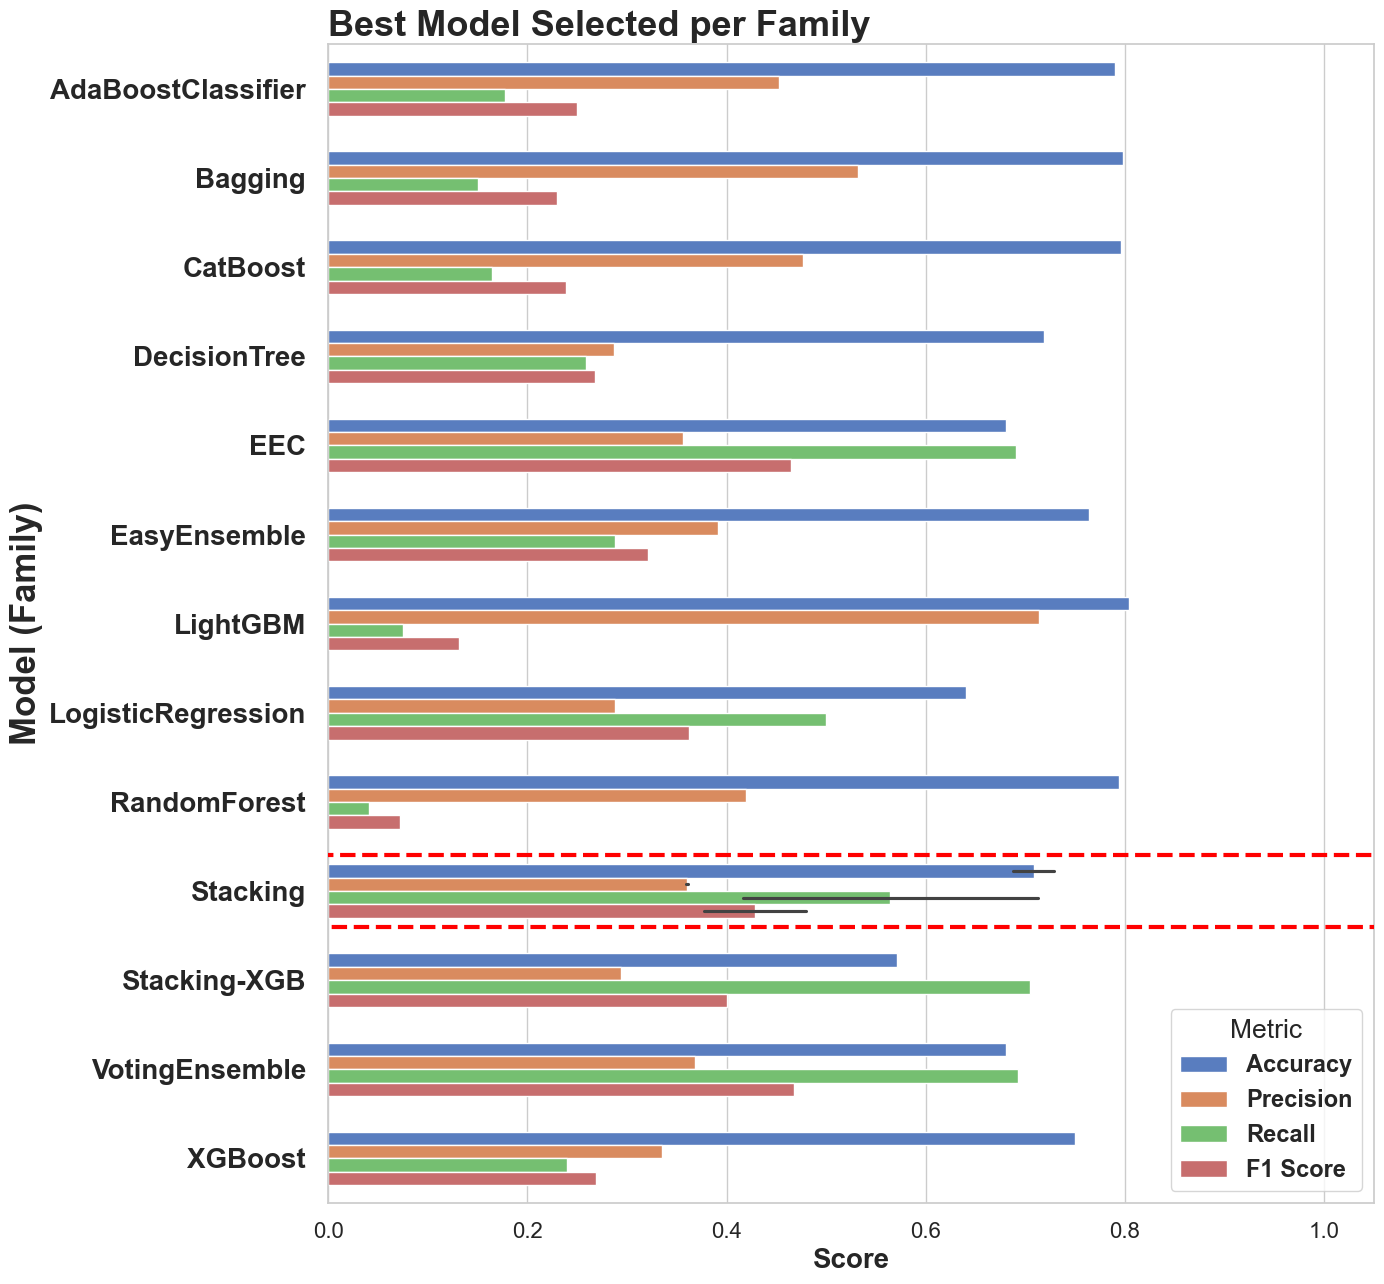

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Rectangle
import re

# Load CSV
df = pd.read_csv("risk_model_metrics.csv")

# --- Remove unwanted models ---
df = df[~df["Name"].str.contains("SVC", case=False)]
df = df[~df["Name"].str.contains("DummyClassifier", case=False)]
df = df[df["Name"] != "ASDSD"]

# Highlighted best model
highlighted_model = "Stacking (CatBoost+EEC+BalancedBagging-LGBM)"

# Manual families mapping
manual_families = {
    "Bagging": ["Bagging","BaggingDT", "BaggingDTClassifier"],
    "DecisionTree": ["DecisionTree", "DecisionTreeClassifier", "DescrionTree"],
    "EasyEnsemble": ["EasyEnsembleClassifier", "EasyEnsemble", "EasyEnsemble-Top20Feat"],
    "RandomForest": ["RandomForest", "RandomForestClassifier"],
    "BalancedBagging": ["BalancedBagging", "BalancedBaggingClassifier"],
}

def get_family(name):
    if name == highlighted_model:
        return highlighted_model
    for fam, variants in manual_families.items():
        if any(v.lower() in name.lower() for v in variants):
            return fam
    if "+" in name:
        return name.split("+")[0]
    return re.split(r"[^A-Za-z]", name)[0]

df["BaseName"] = df["Name"].apply(get_family)
rename_map = {"SDSDDS": "SDSD"}
df["BaseName"] = df["BaseName"].replace(rename_map)

def filter_redundant(df, highlighted_model):
    keep_rows = []
    for base, group in df.groupby("BaseName"):
        if highlighted_model in group["Name"].values:
            best_row = group[group["Name"] == highlighted_model].iloc[0]
        else:
            best_row = group.sort_values(
                by=["Accuracy", "F1 Score", "Recall", "Precision"],
                ascending=[False, False, False, False]
            ).iloc[0]
        keep_rows.append(best_row)
    return pd.DataFrame(keep_rows)

df = filter_redundant(df, highlighted_model)
df.loc[df["Name"] == highlighted_model, "BaseName"] = "Stacking"
df = df.sort_values(by="BaseName").reset_index(drop=True)

# Prepare for plotting
metrics_melted = df.melt(
    id_vars=["BaseName"],
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

# Number of models -> used to scale figure height
n_models = df["BaseName"].nunique()
fig_h = max(8, n_models * 1)   # increased multiplier for more space between models

sns.set(style="whitegrid")
plt.figure(figsize=(14, fig_h))

# Barplot with thinner bars
ax = sns.barplot(
    data=metrics_melted,
    y="BaseName",
    x="Score",
    hue="Metric",
    palette="muted",
    orient="h",
    dodge=True,
    width=0.6,    # thinner bars
    edgecolor=None
)

# Compute y-tick positions and labels
yticks = ax.get_yticks()
yticklabels = [t.get_text() for t in ax.get_yticklabels()]

# Add red rectangle covering all bars of the best model
if "Stacking" in yticklabels:
    idx = yticklabels.index("Stacking")
    ycenter = yticks[idx]
    box_height = 0.8  # cover all bars fully but not overlap neighbors
    box_bottom = ycenter - box_height / 2
    ax.add_patch(Rectangle(
        (0 - 0.01, box_bottom),  # slight offset to cover bars neatly
        1.08,                    # extend slightly beyond max score
        box_height,
        fill=False,
        edgecolor="red",
        linewidth=3,
        linestyle="--",
        zorder=7
    ))

# Styling: bigger fonts and bold labels
plt.title("Best Model Selected per Family", fontsize=26, weight="bold", loc="left")
plt.xlabel("Score", fontsize=20, weight="bold")
plt.ylabel("Model (Family)", fontsize=25, weight="bold")
plt.xlim(0, 1.05)

# Y-axis labels styling
ax.set_yticklabels(yticklabels, fontsize=20, weight="bold")
ax.tick_params(axis="x", labelsize=16, pad=8)
ax.tick_params(axis="y", labelsize=20, pad=10)

# Legend styling
legend = plt.legend(title="Metric", loc="lower right", fontsize=17, title_fontsize=19, frameon=True)
for text in legend.get_texts():
    text.set_weight("bold")

# Layout adjustments
plt.subplots_adjust(left=0.32, right=0.95, top=0.90, bottom=0.06)

# Save and show
os.makedirs("model_performance", exist_ok=True)
plt.tight_layout()
plt.savefig("model_performance/grouped_metrics_per_model.png", dpi=300)
plt.show()
